In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import hierarchicalforecast
import statsforecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS

#### Load Data

In [116]:
df_sales = pd.read_parquet('../../data/gold/dataset_vendas.parquet')
df_sales.head()

,week_date,year,semester,quarter,month,units_sold,region_name,product_attribute_1,product_attribute_2,product_attribute_3,product_name,supplier_name
0,2022-10-31,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
1,2022-11-07,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
2,2022-11-14,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
3,2022-11-21,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6
4,2022-11-28,2022,2,4,11,0.0,Norte,B,C,B24,Product 233,Supplier 6


In [117]:
df_sales.pivot_table(
    index='supplier_name',
    columns='region_name',
    values='units_sold',
    aggfunc='sum',
    fill_value=0
).head()

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\3154514102.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_sales.pivot_table(


region_name,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
supplier_name,,,,,
Supplier 1,0.0,0.0,0.0,0.0,214270.0
Supplier 10,16457.0,108.0,827.0,314.0,1658.0
Supplier 11,0.0,0.0,0.0,0.0,62522.0
Supplier 12,5557.0,13772.0,1781.0,19459.0,10101.0
Supplier 13,24.0,0.0,1.0,195855.0,83521.0


# Descritive statistics

In [120]:
n_weeks = len(df_sales['week_date'].unique())
n_products = len(df_sales['product_name'].unique())
n_suppliers = len(df_sales['supplier_name'].unique())
n_regions = len(df_sales['region_name'].unique())
print(f'Número de semanas: {n_weeks}')
print(f'Número de produtos: {n_products}')
print(f'Número de fornecedores: {n_suppliers}')
print(f'Número de regiões: {n_regions}')

n_series = df_sales.groupby(['product_name', 'supplier_name', 'region_name'],observed=True)['units_sold'].sum().reset_index().shape[0]
print(f'Número de séries temporais: {n_series}')

df_sales.describe()

Número de semanas: 104
Número de produtos: 390
Número de fornecedores: 27
Número de regiões: 5
Número de séries temporais: 2845


,week_date,year,semester,quarter,month,units_sold
count,295880,295880.000000,295880.000000,295880.000000,295880.000000,295880.000000
mean,2023-10-26 11:59:59.999999744,2023.326923,1.500000,2.490385,6.432692,28.785906
min,2022-10-31 00:00:00,2022.000000,1.000000,1.000000,1.000000,0.000000
25%,2023-04-29 06:00:00,2023.000000,1.000000,1.750000,3.750000,0.000000
50%,2023-10-26 12:00:00,2023.000000,1.500000,2.500000,6.500000,0.000000
75%,2024-04-23 18:00:00,2024.000000,2.000000,3.000000,9.000000,5.000000
max,2024-10-21 00:00:00,2024.000000,2.000000,4.000000,12.000000,30384.000000
std,NaN,0.626995,0.500001,1.109361,3.452331,243.292053


Lots of time series, and half of the distribution are zero, which makes it hard to model. Need feature engineering

In [17]:
#exists empty series?
df_sales.groupby(['product_name', 'supplier_name', 'region_name'],observed=True).agg({'units_sold': 'sum'}).reset_index().query('units_sold == 0')

,product_name,supplier_name,region_name,units_sold
350,Product 143,Supplier 3,Nordeste,0.0
351,Product 143,Supplier 6,Centro-Oeste,0.0
354,Product 143,Supplier 6,Sudeste,0.0
2582,Product 66,Supplier 3,Nordeste,0.0


In [18]:
#need to drop empty series before modeling
df_sales_filtered = df_sales.groupby(['product_name', 'supplier_name', 'region_name'],observed=True).filter(lambda x: x['units_sold'].sum() > 0)

In [20]:
n_series = df_sales_filtered.groupby(['product_name', 'supplier_name', 'region_name'],observed=True)['units_sold'].sum().reset_index().shape[0]
print(f'Número de séries temporais: {n_series}')

Número de séries temporais: 2841


In [22]:
df_sales_filtered.describe()

,week_date,year,semester,quarter,month,units_sold
count,295464,295464.000000,295464.000000,295464.000000,295464.000000,295464.000000
mean,2023-10-26 12:00:00,2023.326923,1.500000,2.490385,6.432692,28.826435
min,2022-10-31 00:00:00,2022.000000,1.000000,1.000000,1.000000,0.000000
25%,2023-04-29 06:00:00,2023.000000,1.000000,1.750000,3.750000,0.000000
50%,2023-10-26 12:00:00,2023.000000,1.500000,2.500000,6.500000,0.000000
75%,2024-04-23 18:00:00,2024.000000,2.000000,3.000000,9.000000,5.000000
max,2024-10-21 00:00:00,2024.000000,2.000000,4.000000,12.000000,30384.000000
std,NaN,0.626995,0.500001,1.109361,3.452331,243.460861


#still have some series with zero sales, but we will keep them for now, implies in sparse data and more difficult to model, but we will see how it goes.

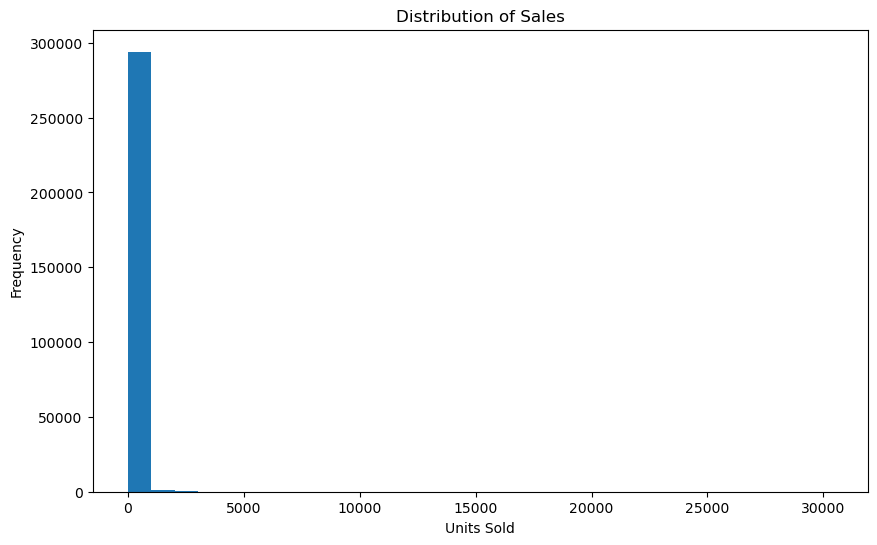

In [23]:
#Analize the distribution of sales 
plt.figure(figsize=(10,6))
plt.hist(df_sales_filtered['units_sold'], bins=30)
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

#very sparse dateset, with many zeros and few high values. We can try to model it with a zero-inflated model or a model that can handle sparse data.

In [25]:
#Analyze top-down hierarchy
df_total_sales = df_sales_filtered.groupby('week_date')['units_sold'].sum().reset_index()
df_total_sales.head()

,week_date,units_sold
0,2022-10-31,114581.0
1,2022-11-07,64134.0
2,2022-11-14,68566.0
3,2022-11-21,39839.0
4,2022-11-28,88060.0


<Axes: xlabel='week_date'>

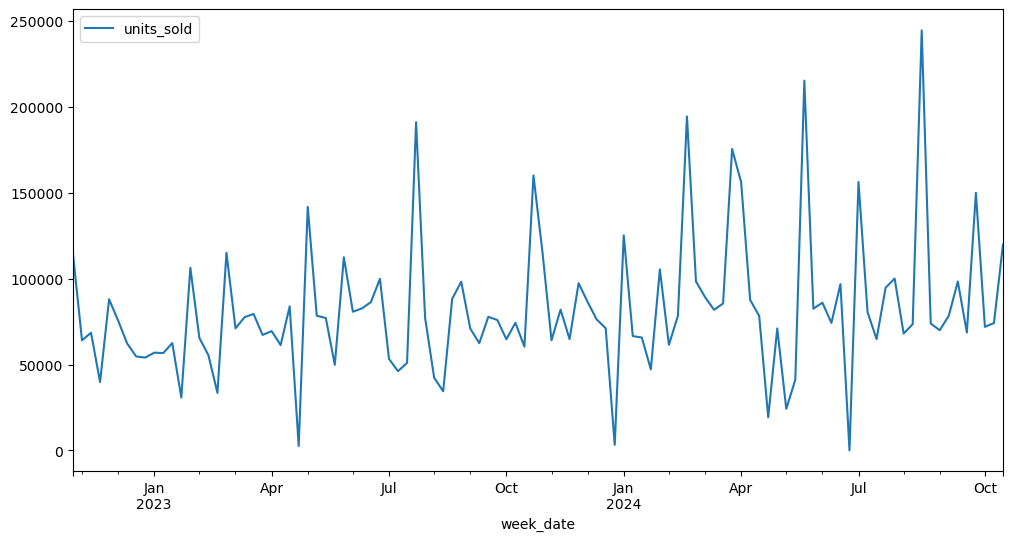

In [26]:
df_total_sales.plot(x='week_date', y='units_sold', kind='line', figsize=(12,6))

### total

In [36]:
#by year
df_total_sales_yearly = df_sales_filtered.groupby(df_sales_filtered['week_date'].dt.year).agg(
    week_date_start=('week_date', 'min'),
    week_date_end=('week_date', 'max'),
    units_sold=('units_sold', 'sum')
).reset_index()
df_total_sales_yearly.rename(columns={'week_date': 'year'}, inplace=True)
df_total_sales_yearly.head()

,year,week_date_start,week_date_end,units_sold
0,2022,2022-10-31,2022-12-26,622040.0
1,2023,2023-01-02,2023-12-25,3896899.0
2,2024,2024-01-01,2024-10-21,3998235.0


<Axes: xlabel='year'>

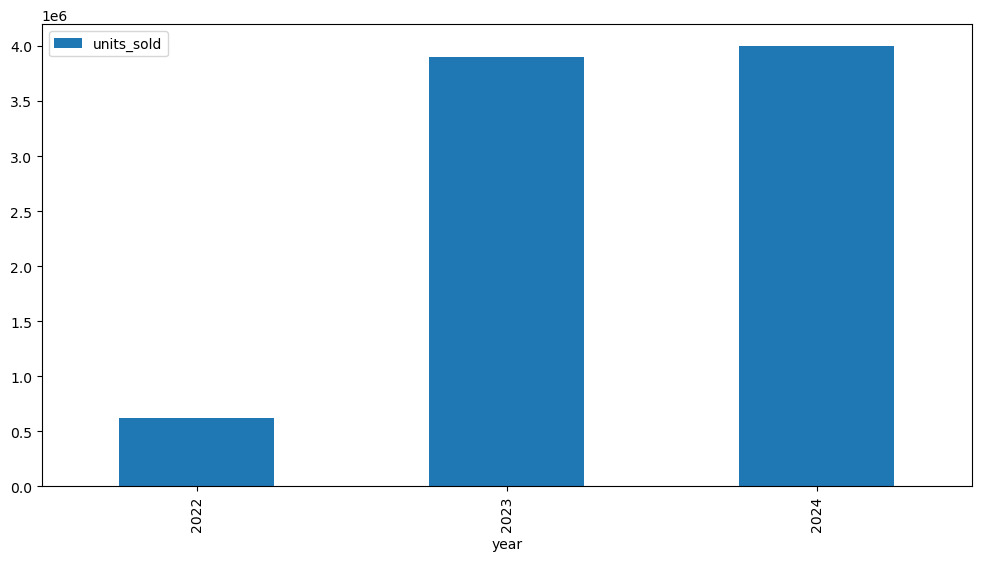

In [37]:
df_total_sales_yearly.plot(x='year', y='units_sold', kind='bar', figsize=(12,6))

#2 years of data, distribuited by 3 years, so we have 2 years with 52 weeks and 1 year with 48 weeks. We can use the first 2 years for training and the last year for testing.

In [39]:
#analyze by month
df_total_sales_monthly = df_sales_filtered.groupby(df_sales_filtered['week_date'].dt.to_period('M')).agg(
    units_sold=('units_sold', 'sum')
).reset_index()
df_total_sales_monthly.rename(columns={'week_date': 'month'}, inplace=True)
df_total_sales_monthly.head()

,month,units_sold
0,2022-10,114581.0
1,2022-11,260599.0
2,2022-12,246860.0
3,2023-01,313500.0
4,2023-02,269736.0


<Axes: xlabel='month'>

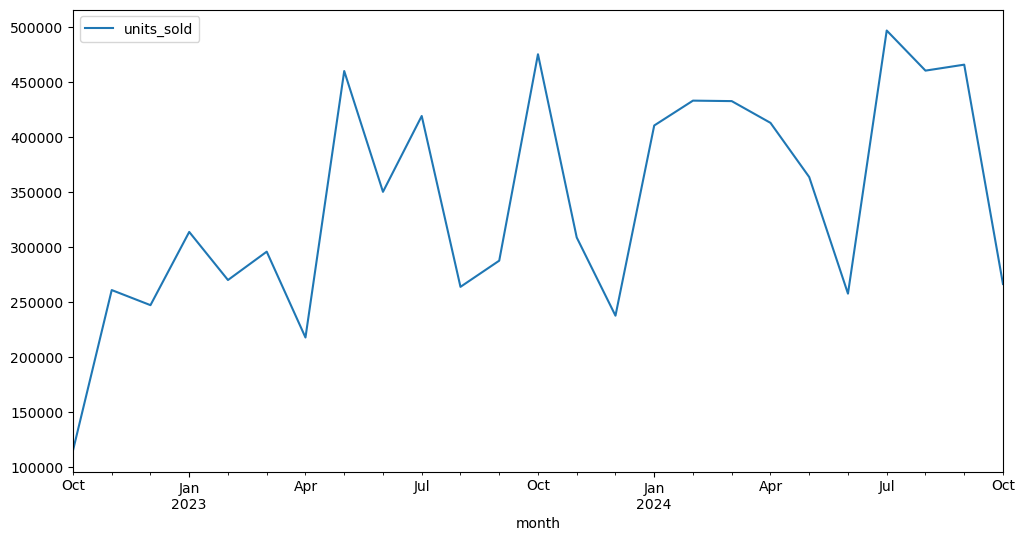

In [40]:
df_total_sales_monthly.plot(x='month', y='units_sold', kind='line', figsize=(12,6))

<Axes: xlabel='month'>

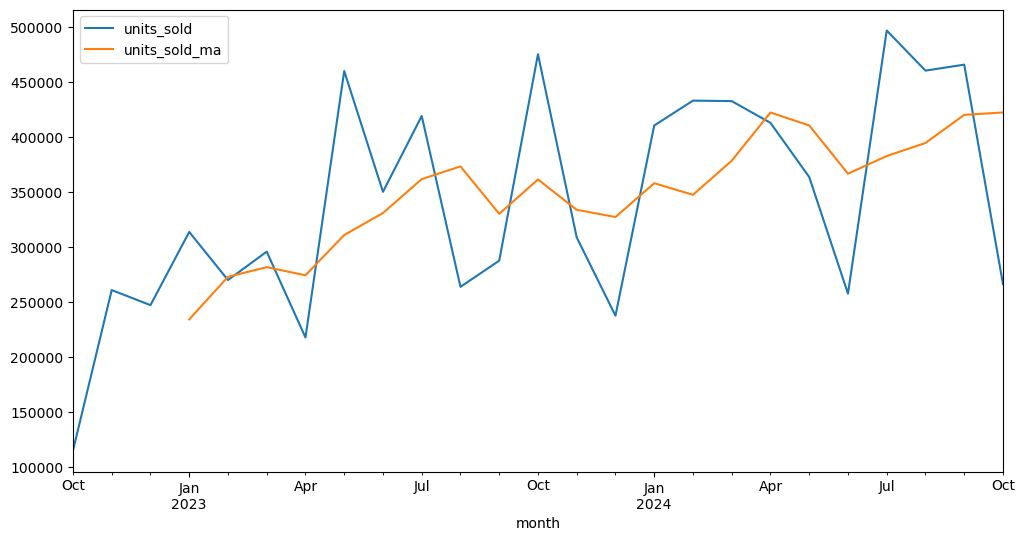

In [41]:
#Trend very clear, but with a lot of noise. We can try to use a moving average to smooth the series and better visualize the trend and seasonality. Let's try a 4-week moving average.
df_total_sales_monthly['units_sold_ma'] = df_total_sales_monthly['units_sold'].rolling(window=4).mean()
df_total_sales_monthly.plot(x='month', y=['units_sold', 'units_sold_ma'], kind='line', figsize=(12,6))

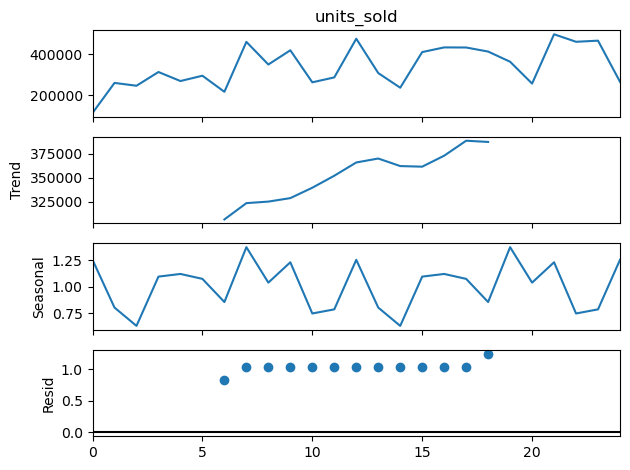

In [124]:
#decompose the series stat

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_total_sales_monthly['units_sold'], model='multiplicative', period=12)
result.plot()
plt.tight_layout()


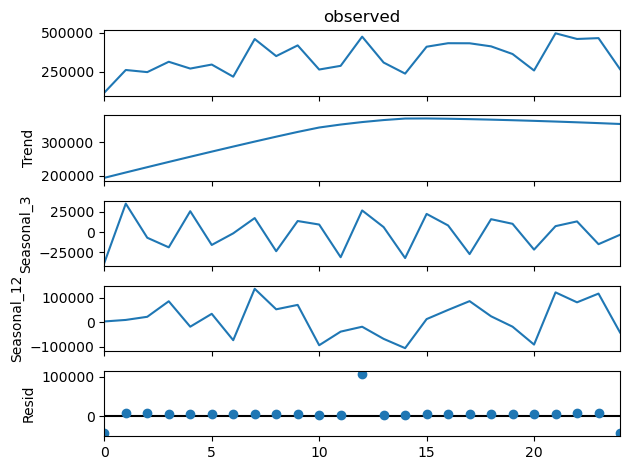

In [126]:
from statsmodels.tsa.seasonal import MSTL

result = MSTL(
    df_total_sales_monthly['units_sold'],
    periods=(3, 12)   # ciclo trimestral + ciclo anual
).fit()

result.plot()
plt.tight_layout()

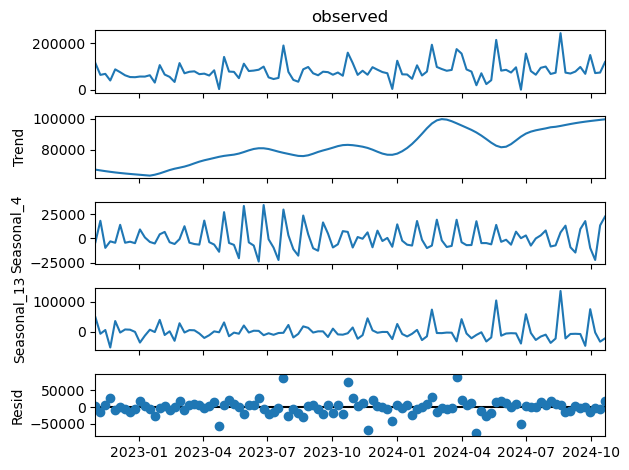

In [138]:
serie_semanal = df_sales_filtered.groupby('week_date')['units_sold'].sum()

result = MSTL(
    serie_semanal,
    periods=(4, 13)  # mensal (~4 sem), trimestral (~13 sem), anual (52 sem)
).fit()

result.plot()
plt.tight_layout()

#Lot of noise in the weekly series good for hierachical reconciliation, maybe because of sparse series

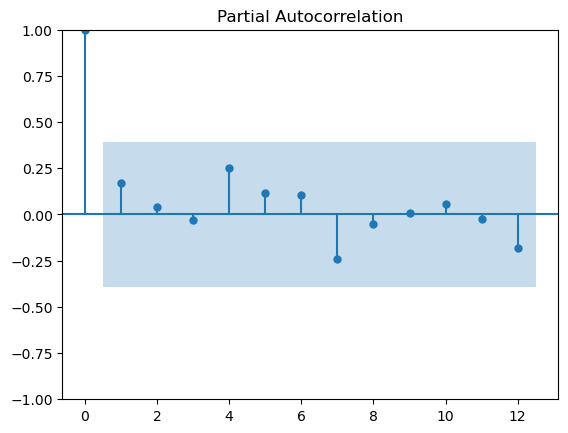

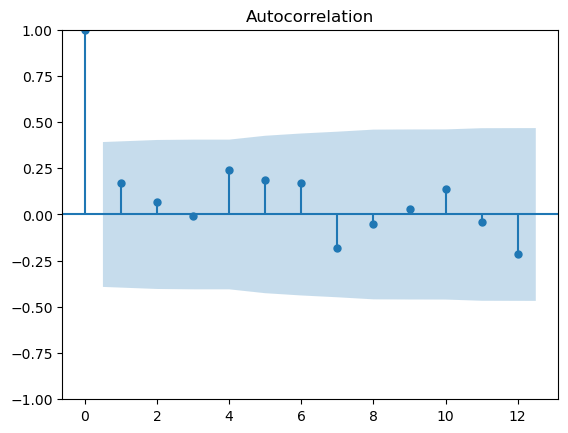

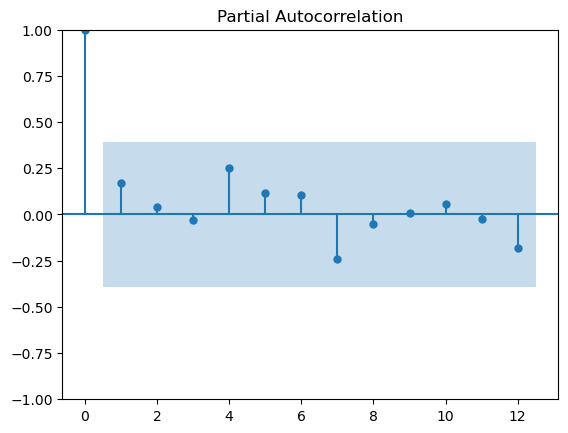

In [49]:
#auto correlation plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_total_sales_monthly['units_sold'], lags=12)
plot_pacf(df_total_sales_monthly['units_sold'], lags=12)

#It implies that in cicle of 12 months we have as trong correlation on lag 4 that can be related to the cicle of the stock refresh

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\872560162.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_region = df_sales_filtered.groupby('region_name')['units_sold'].sum().reset_index().sort_values('units_sold', ascending=False)


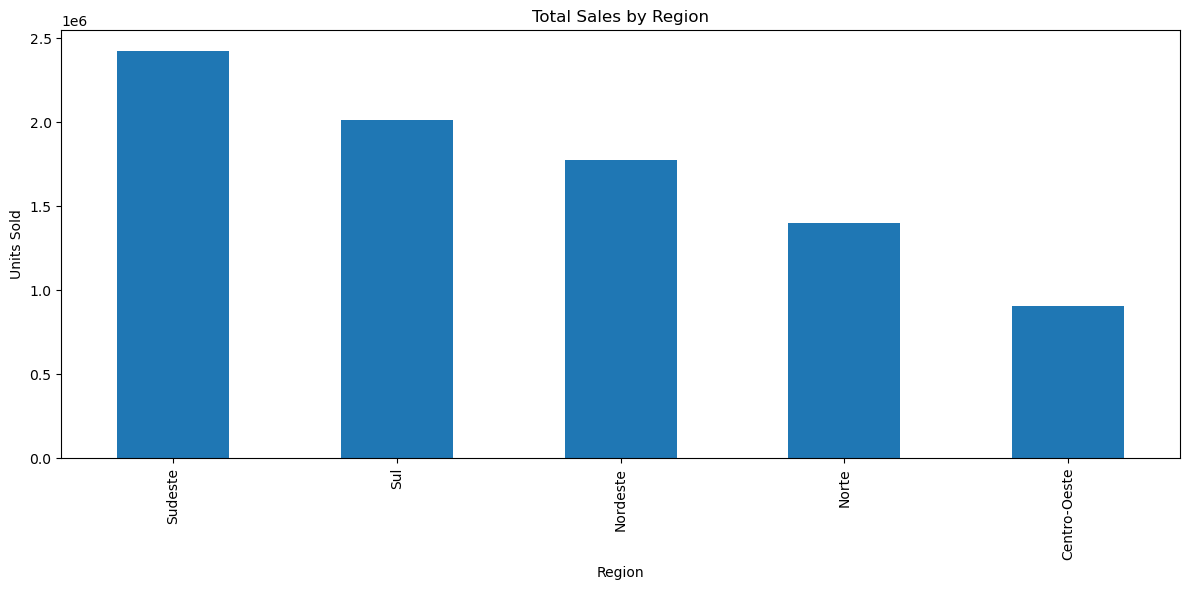

In [54]:
#Analyse total sales by region
df_total_sales_region = df_sales_filtered.groupby('region_name')['units_sold'].sum().reset_index().sort_values('units_sold', ascending=False)
df_total_sales_region.plot(x='region_name', y='units_sold', kind='bar', figsize=(12,6), legend=False)
plt.xlabel('Region')
plt.ylabel('Units Sold')
plt.title('Total Sales by Region')
plt.tight_layout()

In [56]:
df_total_sales_monthly_region.head()

,week_date,region_name,units_sold
0,2022-10,Centro-Oeste,14702.0
1,2022-10,Nordeste,18442.0
2,2022-10,Norte,17640.0
3,2022-10,Sudeste,31974.0
4,2022-10,Sul,31823.0


### Region

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\1388535238.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_region = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'region_name']).agg(


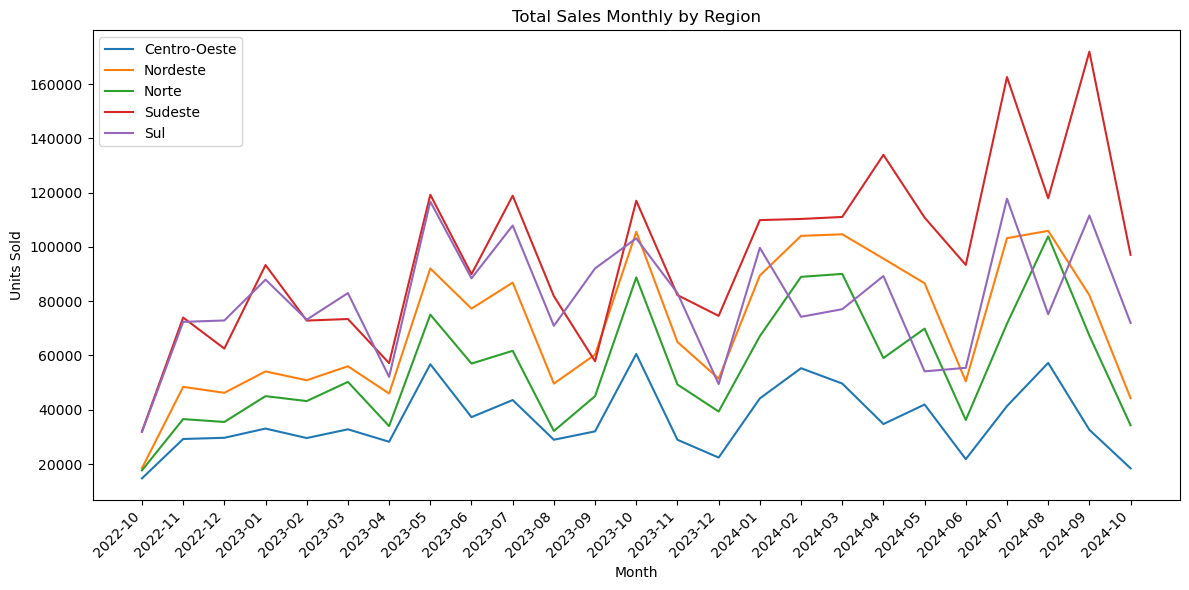

In [74]:
#total sales monthly by region
df_total_sales_monthly_region = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'region_name']).agg(
    units_sold=('units_sold', 'sum')
).reset_index().rename(columns={'week_date': 'month'})

#plot total sales monthly by region
plt.figure(figsize=(12,6))
for region in df_total_sales_monthly_region['region_name'].unique():
    region_data = df_total_sales_monthly_region[df_total_sales_monthly_region['region_name'] == region]
    plt.plot(region_data['month'].astype(str), region_data['units_sold'], label=region)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Region')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\1335030259.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_region = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'region_name']).agg(


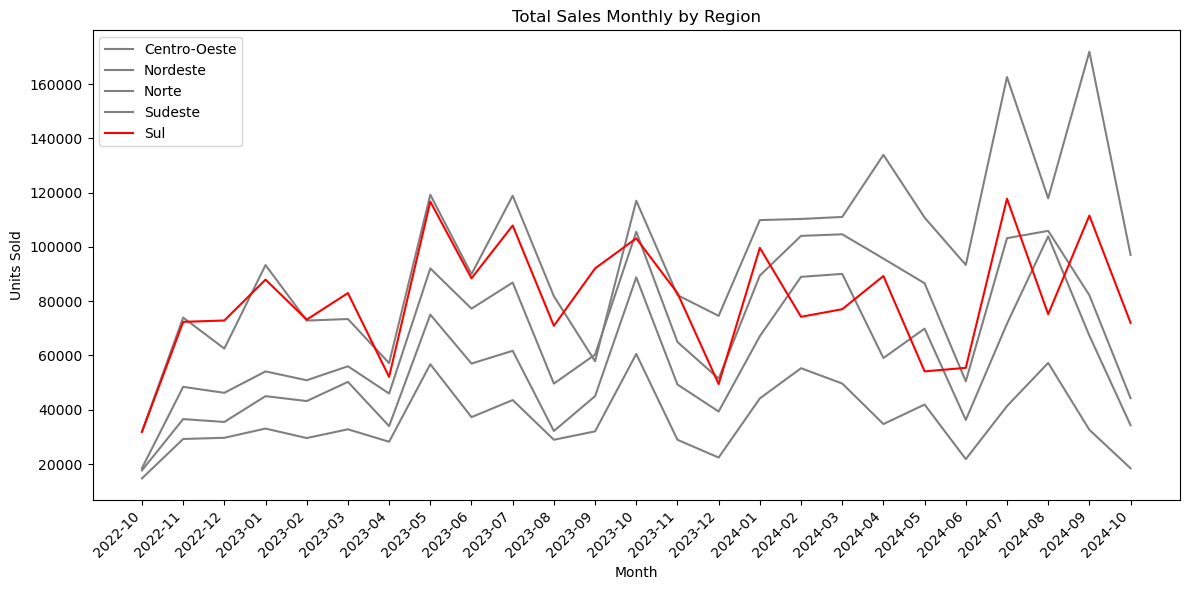

In [81]:
#total sales monthly by region
df_total_sales_monthly_region = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'region_name']).agg(
    units_sold=('units_sold', 'sum')
).reset_index().rename(columns={'week_date': 'month'})

#plot total sales monthly by region
plt.figure(figsize=(12,6))
for region in df_total_sales_monthly_region['region_name'].unique():
    region_data = df_total_sales_monthly_region[df_total_sales_monthly_region['region_name'] == region]
    if region == 'Sul':
        color='red'
    else:
        color='gray'
    plt.plot(region_data['month'].astype(str), region_data['units_sold'], label=region,color=color)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Region')
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
#clustering time series by region
#dinamic time warping distance
from tslearn.metrics import dtw
from tslearn.clustering import TimeSeriesKMeans
from sklearn.preprocessing import StandardScaler

df_total_sales_monthly_region_pivot = df_total_sales_monthly_region.pivot(index='month', columns='region_name', values='units_sold').fillna(0)
scaler = StandardScaler()
df_total_sales_monthly_region_scaled = scaler.fit_transform(df_total_sales_monthly_region_pivot)
model = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=10, random_state=42)
clusters = model.fit_predict(df_total_sales_monthly_region_scaled.T)
df_clusters = pd.DataFrame({'region_name': df_total_sales_monthly_region_pivot.columns, 'cluster': clusters})
print(df_clusters)


    region_name  cluster
0  Centro-Oeste        2
1      Nordeste        1
2         Norte        1
3       Sudeste        0
4           Sul        2


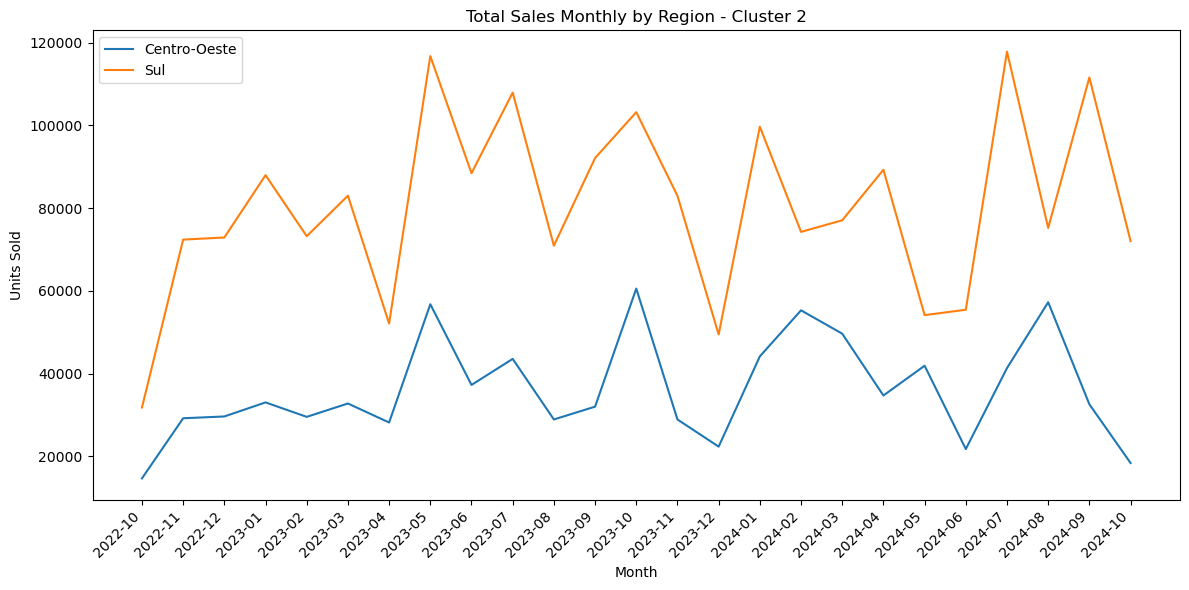

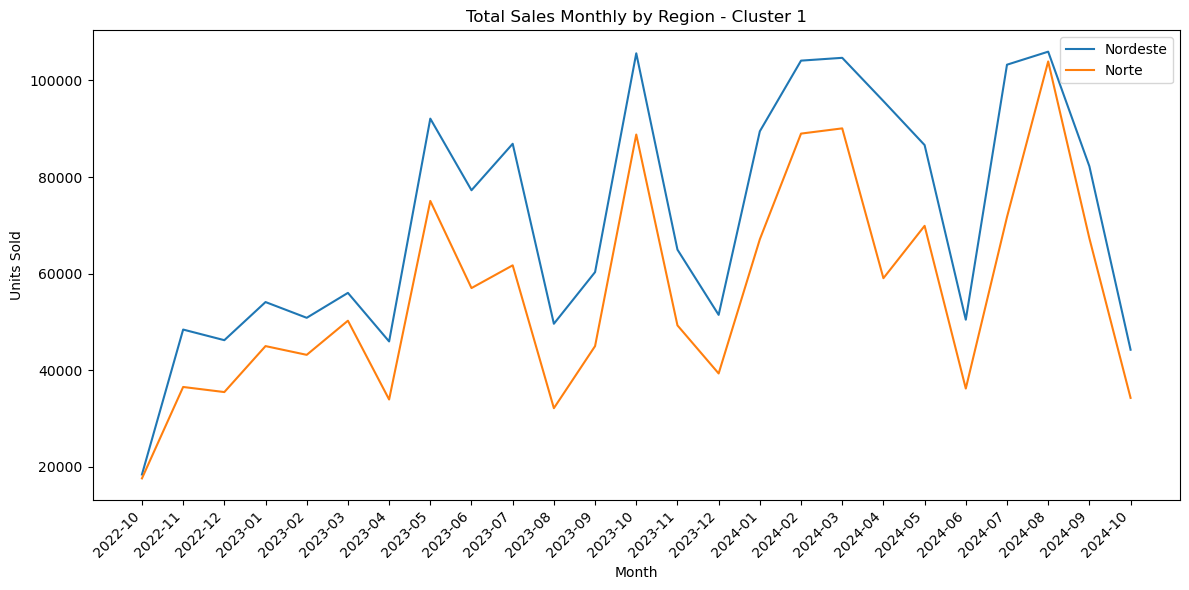

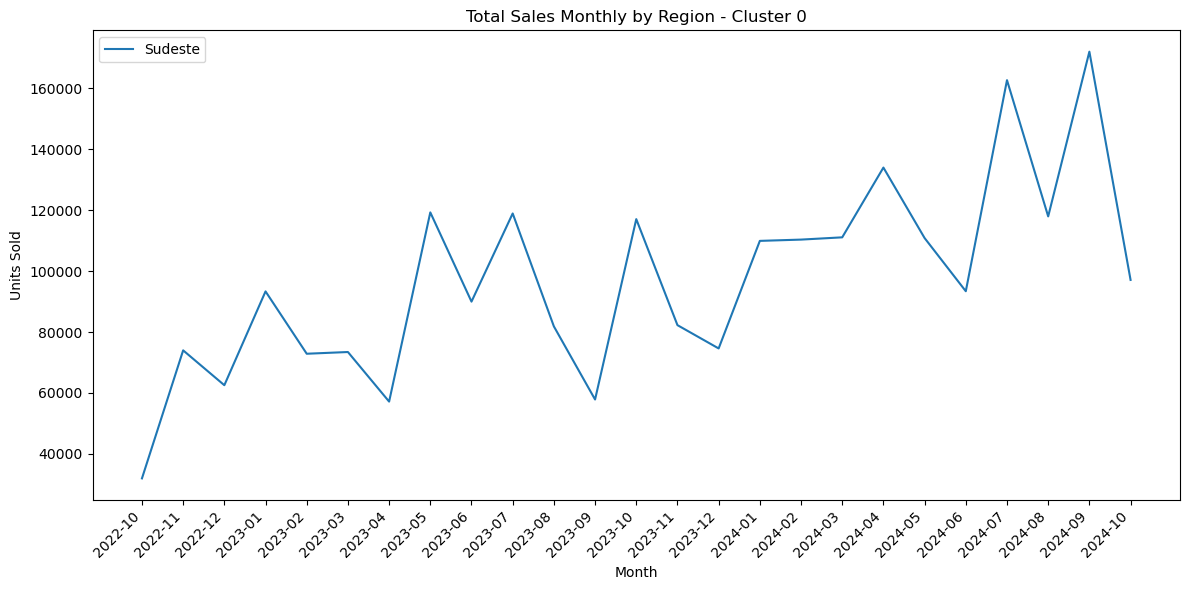

In [75]:
df_total_sales_monthly_region_clustered = df_total_sales_monthly_region.merge(df_clusters, on='region_name')
for cluster in df_clusters['cluster'].unique():
    cluster_data = df_total_sales_monthly_region_clustered[df_total_sales_monthly_region_clustered['cluster'] == cluster]
    plt.figure(figsize=(12,6))
    for region in cluster_data['region_name'].unique():
        region_data = cluster_data[cluster_data['region_name'] == region]
        plt.plot(region_data['month'].astype(str), region_data['units_sold'], label=region)
    plt.xlabel('Month')
    plt.ylabel('Units Sold')
    plt.title(f'Total Sales Monthly by Region - Cluster {cluster}')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

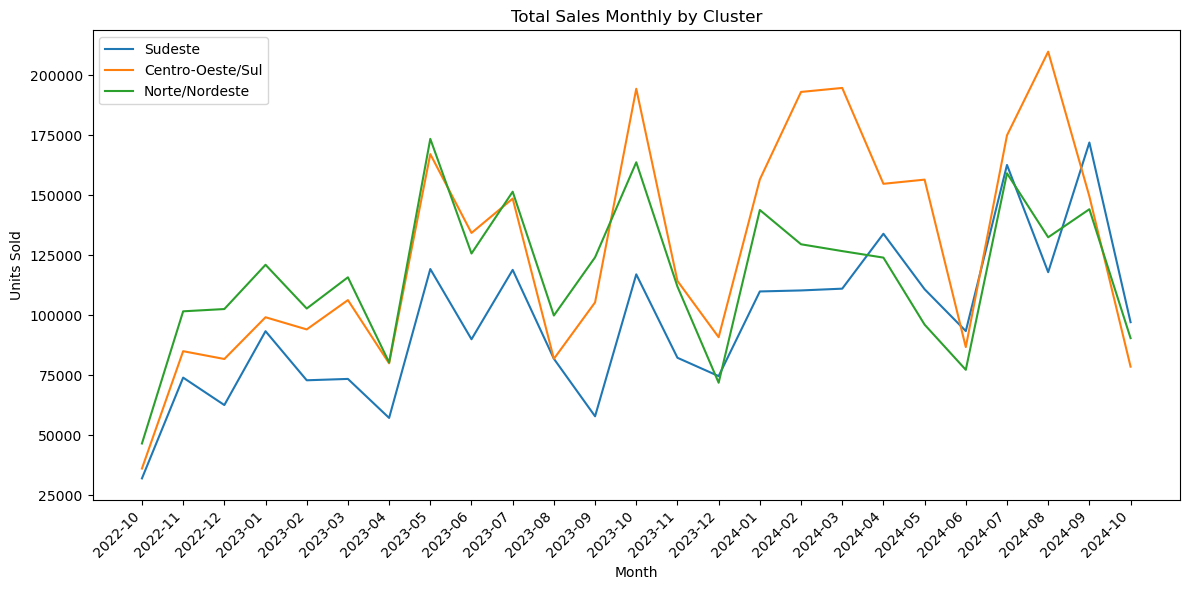

In [73]:
#Analyze gruped by cluster
df_total_sales_monthly_cluster = df_total_sales_monthly_region_clustered.groupby(['month', 'cluster']).agg(
    units_sold=('units_sold', 'sum')
).reset_index()
plt.figure(figsize=(12,6))
for cluster in df_total_sales_monthly_cluster['cluster'].unique():
    if cluster == 0:
        cluster_name = 'Sudeste'
    elif cluster == 1:
        cluster_name = 'Centro-Oeste/Sul'
    else:
        cluster_name = 'Norte/Nordeste'
    cluster_data = df_total_sales_monthly_cluster[df_total_sales_monthly_cluster['cluster'] == cluster]
    plt.plot(cluster_data['month'].astype(str), cluster_data['units_sold'], label=f'{cluster_name}')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Cluster')
plt.legend()
plt.tight_layout()
plt.show()

#All series by reagion tends to grow and volatility as well, sudeste is more stable, sul and centro-oeste more volatilty, sul has the tragedy of the flood (april-24) can justify 2 diferent ciclesm 

### Supplier analysis

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\3889696261.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_supprier = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'supplier_name']).agg(


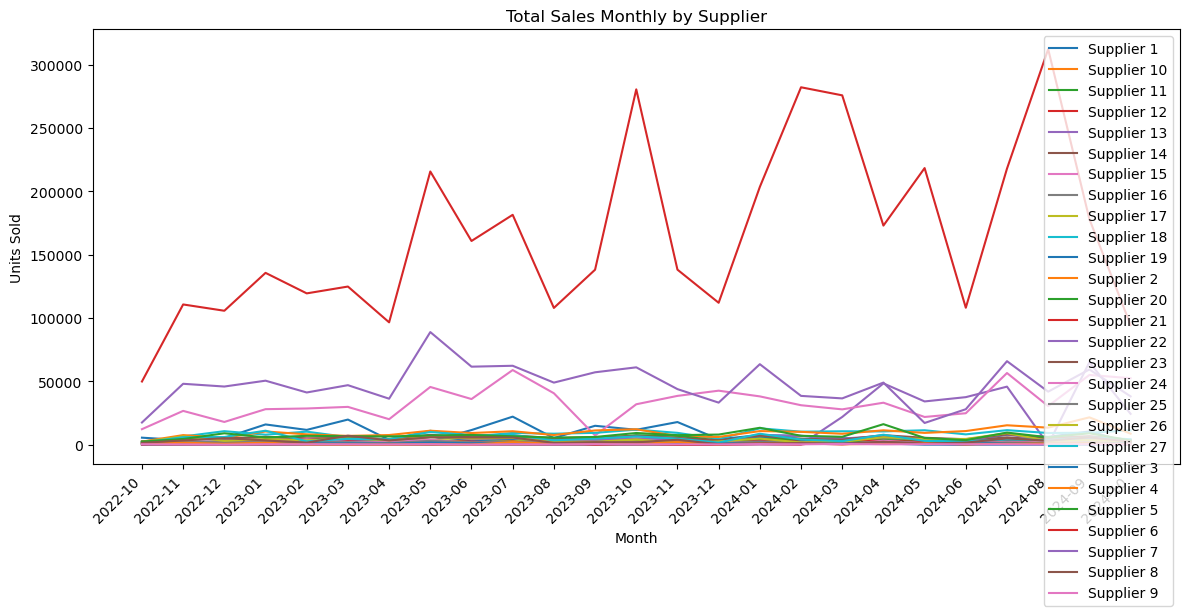

In [95]:
df_total_sales_monthly_supprier = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'supplier_name']).agg(
    units_sold=('units_sold', 'sum')
).reset_index().rename(columns={'week_date': 'month'})

#plot total sales monthly by supplier
plt.figure(figsize=(12,6))
for supplier in df_total_sales_monthly_supprier['supplier_name'].unique():
    supplier_data = df_total_sales_monthly_supprier[df_total_sales_monthly_supprier['supplier_name'] == supplier]
    plt.plot(supplier_data['month'].astype(str), supplier_data['units_sold'], label=supplier)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Supplier')
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
df_total_sales_monthly_supprier.groupby('supplier_name')['units_sold'].sum().sort_values(ascending=False).head()

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\212188628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_supprier.groupby('supplier_name')['units_sold'].sum().sort_values(ascending=False).head()


supplier_name
Supplier 6     4140624.0
Supplier 7     1181271.0
Supplier 15     836079.0
Supplier 13     279401.0
Supplier 2      242967.0
Name: units_sold, dtype: float32

#supplier 6 is much more higher than the others, we can try to analyze it separately

In [94]:
df_sales.pivot_table(
    index='product_name',
    columns='supplier_name',
    values='units_sold',
    aggfunc='sum',
    fill_value=0
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\948782469.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_sales.pivot_table(


supplier_name,Supplier 1,Supplier 10,Supplier 11,Supplier 12,Supplier 13,Supplier 14,Supplier 15,Supplier 16,Supplier 17,Supplier 18,...,Supplier 25,Supplier 26,Supplier 27,Supplier 3,Supplier 4,Supplier 5,Supplier 6,Supplier 7,Supplier 8,Supplier 9
product_name,,,,,,,,,,,,,,,,,,,,,
Product 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,66.0,0.0,0.0,0.0
Product 10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3539.0,0.0,0.0
Product 100,0.0,0.0,266.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,...,587.0,0.0,0.0,23.0,0.0,0.0,10098.0,2401.0,0.0,0.0
Product 101,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,412.0,0.0,0.0,0.0,0.0,0.0,196.0,0.0,0.0,0.0
Product 102,0.0,0.0,2216.0,0.0,0.0,103.0,0.0,0.0,0.0,0.0,...,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Product 95,0.0,0.0,0.0,0.0,0.0,17.0,0.0,2183.0,0.0,0.0,...,0.0,0.0,0.0,37.0,0.0,0.0,3142.0,0.0,165.0,0.0
Product 96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,245.0,0.0,0.0,0.0
Product 97,5.0,60.0,0.0,0.0,0.0,0.0,3989.0,0.0,0.0,1165.0,...,0.0,1252.0,0.0,52.0,5.0,0.0,12135.0,5007.0,0.0,8.0


Same product can be supplied by different suppliers, and the same supplier can supply different products. This creates a complex hierarchy that can be explored for forecasting. We can analyze the sales by product and supplier to identify patterns and trends that can inform our forecasting models.

### products

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\668555935.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_product = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'product_name']).agg(


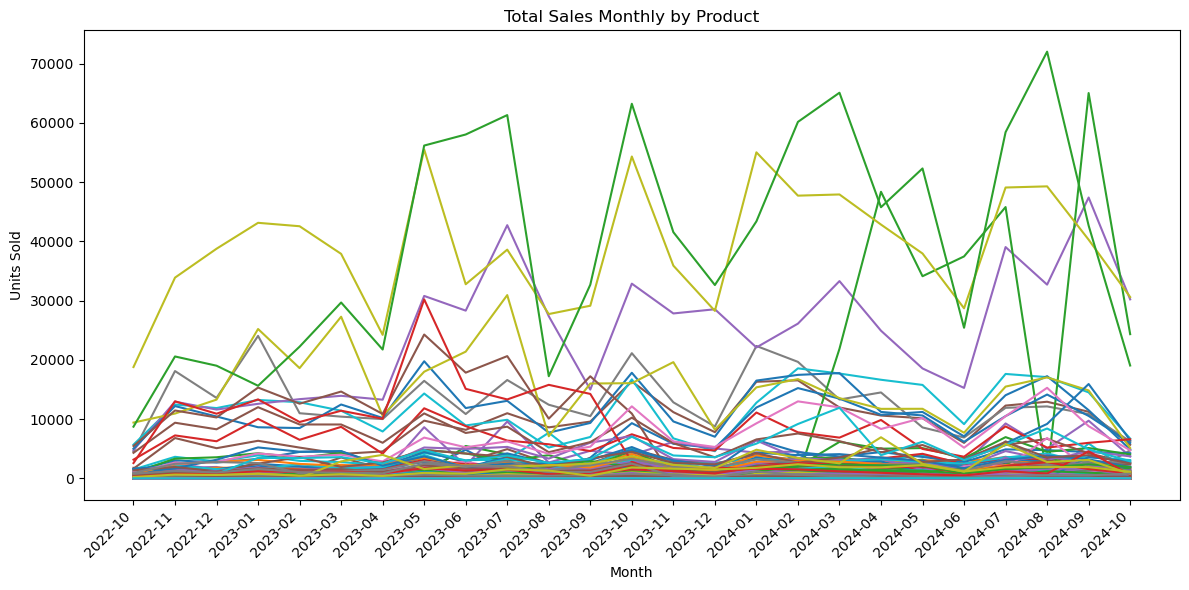

In [101]:
df_total_sales_monthly_product = df_sales_filtered.groupby([df_sales_filtered['week_date'].dt.to_period('M'), 'product_name']).agg(
    units_sold=('units_sold', 'sum')
).reset_index().rename(columns={'week_date': 'month'})

#plot total sales monthly by product
plt.figure(figsize=(12,6))
for product in df_total_sales_monthly_product['product_name'].unique():
    product_data = df_total_sales_monthly_product[df_total_sales_monthly_product['product_name'] == product]
    plt.plot(product_data['month'].astype(str), product_data['units_sold'], label=product)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales Monthly by Product')
plt.tight_layout()
plt.show()


In [106]:
df_total_sales_monthly_product.groupby('product_name')['units_sold'].sum().sort_values()

C:\Users\eduar\AppData\Local\Temp\ipykernel_13084\4113076736.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_sales_monthly_product.groupby('product_name')['units_sold'].sum().sort_values()


product_name
Product 143       100.0
Product 1         109.0
Product 32        110.0
Product 82        115.0
Product 233       116.0
                 ...   
Product 123    327713.0
Product 241    381948.0
Product 166    605441.0
Product 205    970702.0
Product 326    984563.0
Name: units_sold, Length: 390, dtype: float32

#Lot variability in products dimension even by monthly sales. This can be a problem for modeling, since some products have very low sales and others have very high sales. We can try to group products by clustering.

In [139]:
from hierarchicalforecast.utils import aggregate

# 1. Preparar o dataframe no formato esperado (unique_id, ds, y)
df_hier = (
    df_sales_filtered[['week_date', 'supplier_name', 'region_name', 'product_name', 'units_sold']]
    .rename(columns={'week_date': 'ds', 'units_sold': 'y'})
    .copy()
)

# 2. Definir a hierarquia agrupada (spec = do mais agregado ao bottom)
# "Total" é adicionado automaticamente pela função
spec = [
    ['supplier_name'],                                    # 27 séries
    ['region_name'],                                      # 5 séries
    ['supplier_name', 'region_name'],                     # ~130 séries
    ['supplier_name', 'region_name', 'product_name'],     # 2.841 séries (bottom)
]

# 3. Gerar Y_df, S_df e tags
Y_df, S_df, tags = aggregate(df=df_hier, spec=spec)

print(f"Total de séries: {S_df.shape[0]}")
print(f"Séries bottom-level: {S_df.shape[1]}")
print("\nNíveis e quantidades:")
for level, ids in tags.items():
    print(f"  {level}: {len(ids)} séries")


c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_native = df._native_frame.groupby(partition_by)[
c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_native = df._native_frame.groupby(partition_by)[
c:\Users\eduar\AppData\Local\anaconda3\envs\or-env\lib\site-packages\narwhals\_pandas_like\expr.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

Total de séries: 2925
Séries bottom-level: 2842

Níveis e quantidades:
  supplier_name: 27 séries
  region_name: 5 séries
  supplier_name/region_name: 52 séries
  supplier_name/region_name/product_name: 2841 séries


In [140]:
Y_df

,unique_id,ds,y
0,Supplier 1,2022-10-31,5519.0
1,Supplier 1,2022-11-07,863.0
2,Supplier 1,2022-11-14,1101.0
3,Supplier 1,2022-11-21,523.0
4,Supplier 1,2022-11-28,1057.0
...,...,...,...
304195,Supplier 9/Nordeste/Product 98,2024-09-23,0.0
304196,Supplier 9/Nordeste/Product 98,2024-09-30,0.0
304197,Supplier 9/Nordeste/Product 98,2024-10-07,0.0
304198,Supplier 9/Nordeste/Product 98,2024-10-14,0.0


In [141]:
def classify_series(y: pd.Series) -> str:
    """Croston's demand classification: Smooth, Erratic, Intermittent, Lumpy"""
    non_zero = y[y > 0]
    if len(non_zero) == 0:
        return 'Empty'
    
    adi = len(y) / len(non_zero)          # Avg Demand Interval
    cv2 = (non_zero.std() / non_zero.mean()) ** 2  # Coef. of Variation²
    
    if adi < 1.32 and cv2 < 0.49:
        return 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49:
        return 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49:
        return 'Intermittent'
    else:
        return 'Lumpy'

demand_profile = (
    Y_df.groupby('unique_id')['y']
    .apply(classify_series)
    .reset_index()
    .rename(columns={'y': 'demand_type'})
)

# adiciona nível hierárquico
demand_profile['level'] = demand_profile['unique_id'].apply(
    lambda x: 'bottom' if x.count('/') == 2 else ('total' if x == 'Total' else 'mid')
)

print(demand_profile.groupby(['level', 'demand_type']).size().unstack(fill_value=0))


demand_type  Erratic  Intermittent  Lumpy  Smooth
level                                            
bottom           596           933   1197     115
mid               24            10     16      34


In [142]:
zero_pct = (
    Y_df.groupby('unique_id')['y']
    .apply(lambda x: (x == 0).mean())
    .reset_index()
    .rename(columns={'y': 'zero_pct'})
)

# distribuição por nível
for level_name, ids in tags.items():
    subset = zero_pct[zero_pct['unique_id'].isin(ids)]['zero_pct']
    print(f"{level_name}: mediana zeros = {subset.median():.1%}, max = {subset.max():.1%}")


supplier_name: mediana zeros = 3.8%, max = 63.5%
region_name: mediana zeros = 1.0%, max = 1.0%
supplier_name/region_name: mediana zeros = 15.4%, max = 99.0%
supplier_name/region_name/product_name: mediana zeros = 62.5%, max = 99.0%


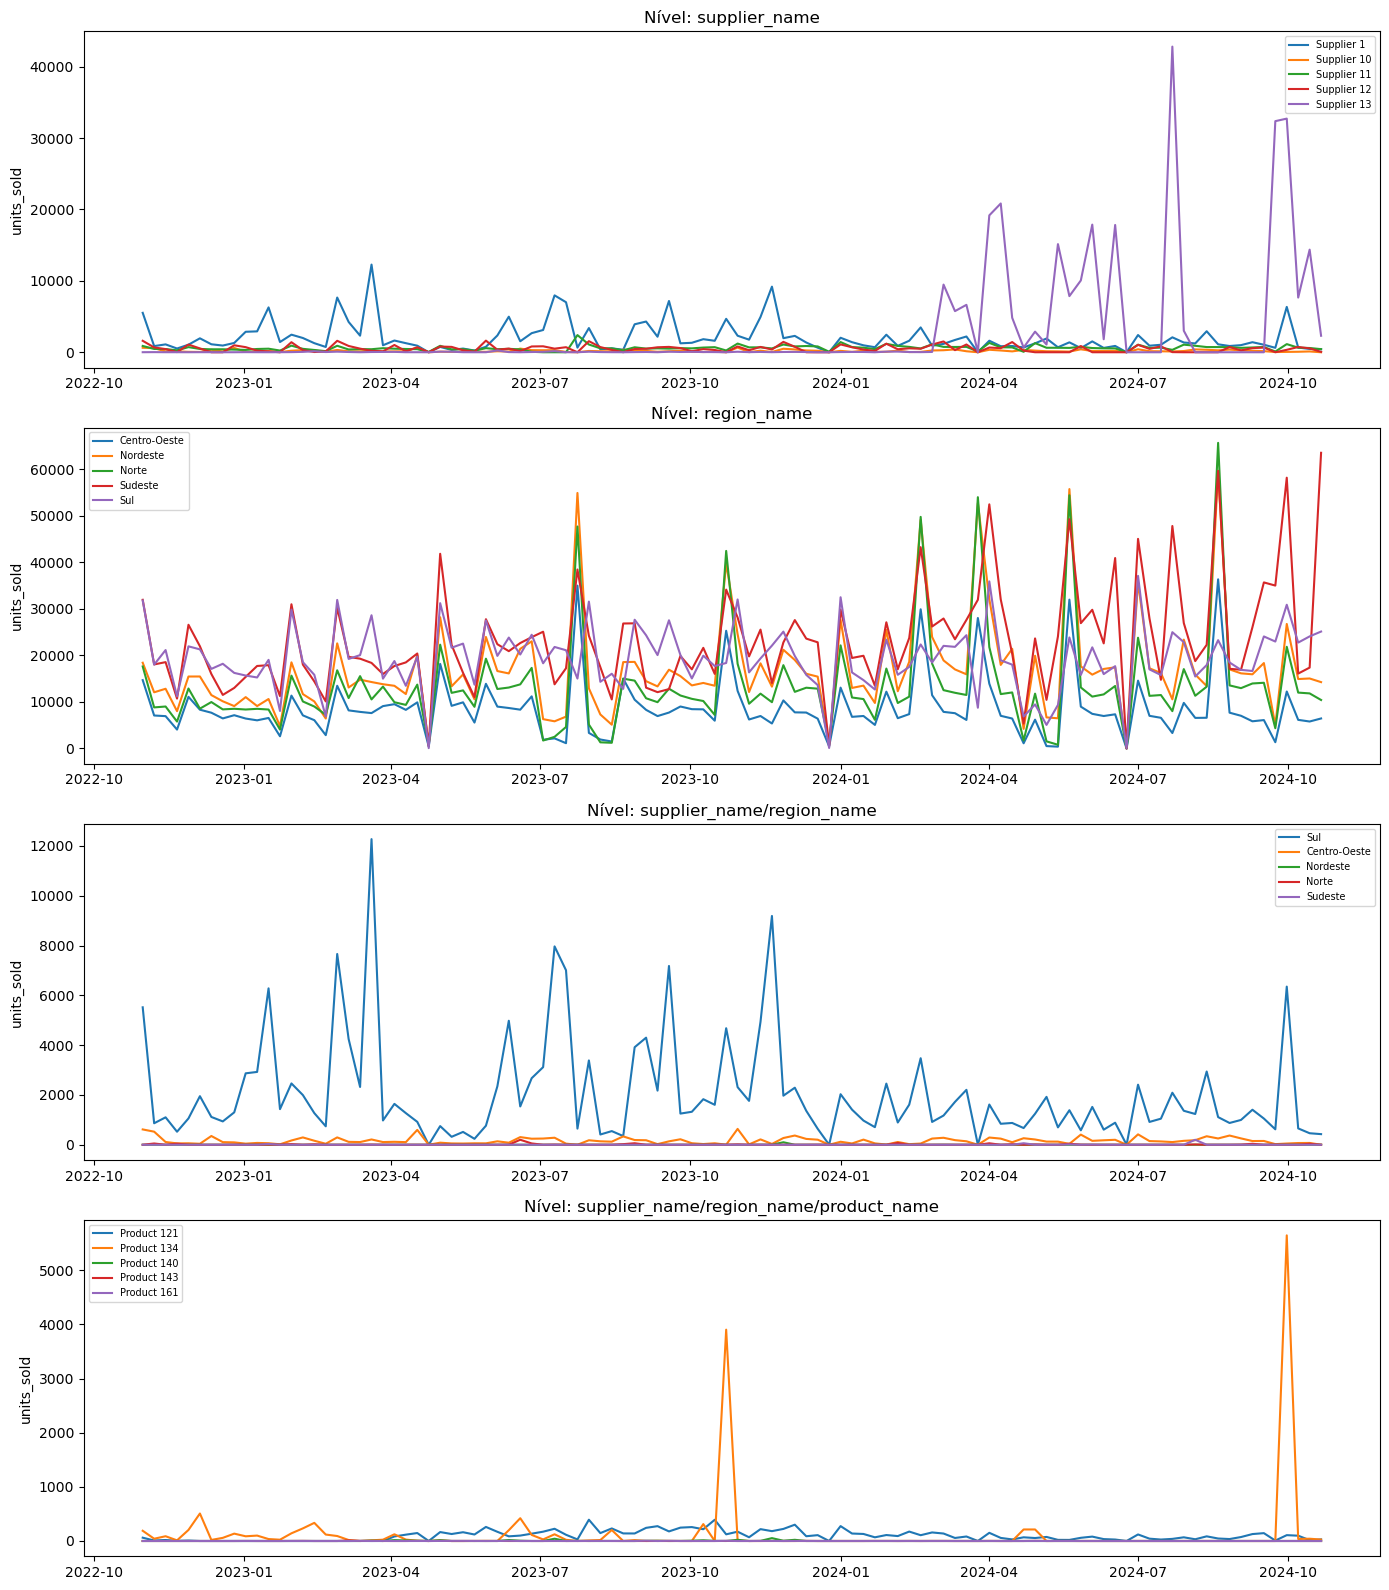

In [143]:
fig, axes = plt.subplots(len(tags), 1, figsize=(14, 4 * len(tags)))

for ax, (level_name, ids) in zip(axes, tags.items()):
    sample_ids = ids[:5] if len(ids) > 5 else ids
    for uid in sample_ids:
        s = Y_df[Y_df['unique_id'] == uid].set_index('ds')['y']
        ax.plot(s.index, s.values, label=uid.split('/')[-1])
    ax.set_title(f'Nível: {level_name}')
    ax.legend(fontsize=7)
    ax.set_ylabel('units_sold')

plt.tight_layout()
plt.show()


In [146]:
# Todas as séries bottom-level do Product 134
p134_bottom = Y_df[
    Y_df['unique_id'].str.endswith('Product 134')
]

# Detectar outlier por série com z-score
from scipy import stats
import numpy as np
import pandas as pd

outlier_report = []

for uid, group in p134_bottom.groupby('unique_id'):
    # Resetar index para facilitar manipulação
    group = group.reset_index(drop=True)
    y = group['y'].values
    
    # Filtrar apenas valores positivos
    positive_mask = y > 0
    
    if positive_mask.sum() > 3:  # Precisa de pelo menos 3 valores positivos
        # Calcular z-score apenas nos valores positivos
        y_positive = y[positive_mask]
        z_scores = np.abs(stats.zscore(y_positive))
        
        # Encontrar o pior outlier
        if z_scores.max() > 3:
            # Índice do pior outlier dentro dos valores positivos
            worst_idx_in_positive = z_scores.argmax()
            
            # Mapear de volta para índice original
            positive_indices = np.where(positive_mask)[0]
            worst_idx_original = positive_indices[worst_idx_in_positive]
            
            outlier_report.append({
                'unique_id': uid,
                'ds': group.loc[worst_idx_original, 'ds'],
                'value': group.loc[worst_idx_original, 'y'],
                'zscore': z_scores.max()
            })

# Criar DataFrame e ordenar
if len(outlier_report) > 0:
    df_outliers = pd.DataFrame(outlier_report).sort_values('zscore', ascending=False)
    print("\n📊 Outliers Detectados (Z-score > 3):")
    print(df_outliers.to_string(index=False))
    
    # Estatísticas resumidas
    print(f"\n📈 Total de séries com outliers: {len(df_outliers)}")
    print(f"📈 Z-score máximo: {df_outliers['zscore'].max():.2f}")
    print(f"📈 Z-score médio: {df_outliers['zscore'].mean():.2f}")
else:
    print("\n✅ Nenhum outlier detectado (Z-score > 3)")


📊 Outliers Detectados (Z-score > 3):
                          unique_id         ds  value   zscore
    Supplier 6/Nordeste/Product 134 2024-08-19 1361.0 5.835094
         Supplier 1/Sul/Product 134 2024-09-30 5646.0 5.587494
    Supplier 25/Sudeste/Product 134 2022-10-31  236.0 5.394898
Supplier 6/Centro-Oeste/Product 134 2022-10-31  586.0 5.178727
     Supplier 6/Sudeste/Product 134 2024-05-20 4873.0 4.804887
         Supplier 7/Sul/Product 134 2024-10-14  937.0 4.510668
       Supplier 6/Norte/Product 134 2023-07-24   26.0 4.448127
         Supplier 4/Sul/Product 134 2023-07-31  985.0 4.193954
    Supplier 22/Sudeste/Product 134 2024-07-22 2197.0 4.045862
         Supplier 6/Sul/Product 134 2024-03-25 3107.0 3.584803

📈 Total de séries com outliers: 10
📈 Z-score máximo: 5.84
📈 Z-score médio: 4.76



📊 RELATÓRIO DE OUTLIERS - Product 134

🔴 Pior outlier por série:
                          unique_id         ds  value   zscore
    Supplier 6/Nordeste/Product 134 2024-08-19 1361.0 5.835094
         Supplier 1/Sul/Product 134 2024-09-30 5646.0 5.587494
    Supplier 25/Sudeste/Product 134 2022-10-31  236.0 5.394898
Supplier 6/Centro-Oeste/Product 134 2022-10-31  586.0 5.178727
     Supplier 6/Sudeste/Product 134 2024-05-20 4873.0 4.804887
         Supplier 7/Sul/Product 134 2024-10-14  937.0 4.510668
       Supplier 6/Norte/Product 134 2023-07-24   26.0 4.448127
         Supplier 4/Sul/Product 134 2023-07-31  985.0 4.193954
    Supplier 22/Sudeste/Product 134 2024-07-22 2197.0 4.045862
         Supplier 6/Sul/Product 134 2024-03-25 3107.0 3.584803

📊 Estatísticas:
   - Total de séries analisadas: 15
   - Séries com outliers: 10
   - Total de outliers detectados: 23
   - Z-score máximo: 5.84
   - Z-score médio: 4.22

📈 Outliers por série:
unique_id
Supplier 6/Sudeste/Product 134       

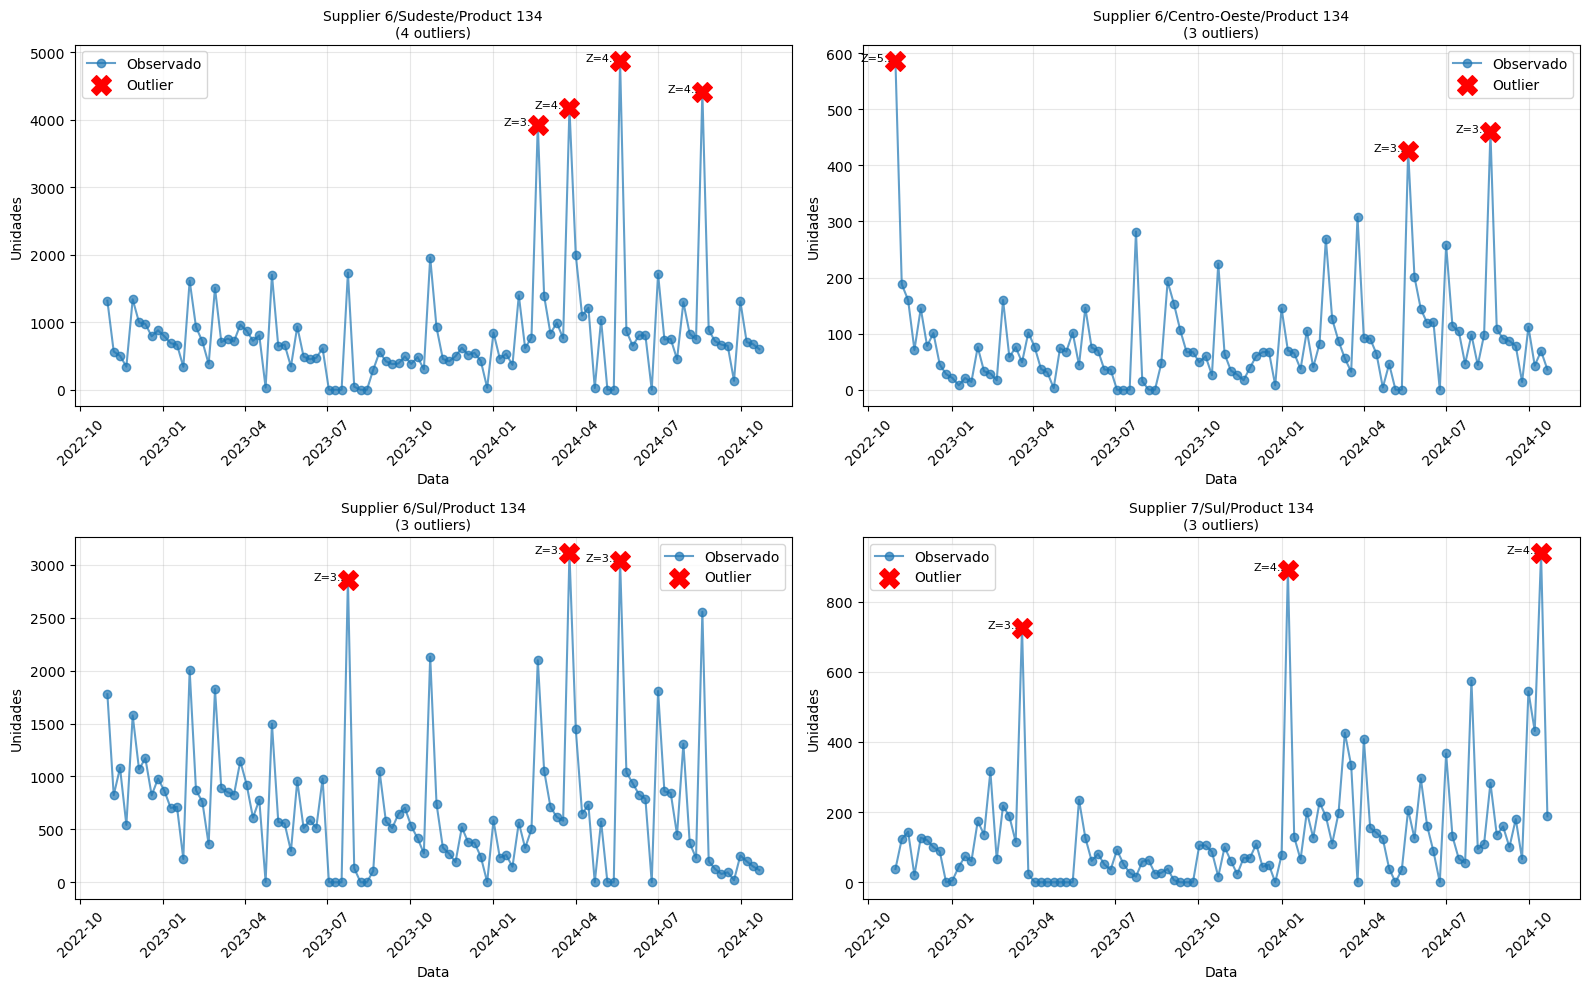

In [147]:
from scipy import stats
import numpy as np
import pandas as pd

# Todas as séries bottom-level do Product 134
p134_bottom = Y_df[
    Y_df['unique_id'].str.endswith('Product 134')
].copy()

# Função para detectar outliers
def detect_outliers(series, threshold=3, method='zscore'):
    """
    Detecta outliers em uma série temporal
    
    Parameters:
    -----------
    series : array-like
        Série temporal
    threshold : float
        Limiar para considerar outlier (padrão: 3 para z-score)
    method : str
        'zscore', 'iqr', ou 'modified_zscore'
    
    Returns:
    --------
    outlier_mask : boolean array
        True onde há outliers
    scores : array
        Scores calculados
    """
    # Filtrar zeros
    mask_nonzero = series > 0
    if mask_nonzero.sum() < 3:
        return np.zeros(len(series), dtype=bool), np.zeros(len(series))
    
    values = series[mask_nonzero]
    
    if method == 'zscore':
        # Z-score padrão
        z = np.abs(stats.zscore(values))
        outlier_idx = z > threshold
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = z
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores
    
    elif method == 'iqr':
        # Interquartile Range (mais robusto a outliers extremos)
        Q1 = np.percentile(values, 25)
        Q3 = np.percentile(values, 75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        outlier_idx = (values < lower_bound) | (values > upper_bound)
        
        # Calcular "score" como distância normalizada
        scores = np.maximum(
            np.abs(values - Q1) / IQR,
            np.abs(values - Q3) / IQR
        )
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = scores
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores
    
    elif method == 'modified_zscore':
        # Modified Z-score (usa mediana, mais robusto)
        median = np.median(values)
        mad = np.median(np.abs(values - median))
        
        if mad == 0:
            mad = np.mean(np.abs(values - median))
        
        modified_z = 0.6745 * (values - median) / mad if mad > 0 else np.zeros(len(values))
        outlier_idx = np.abs(modified_z) > threshold
        
        # Mapear de volta
        full_scores = np.zeros(len(series))
        full_scores[mask_nonzero] = np.abs(modified_z)
        
        full_outliers = np.zeros(len(series), dtype=bool)
        outlier_positions = np.where(mask_nonzero)[0][outlier_idx]
        full_outliers[outlier_positions] = True
        
        return full_outliers, full_scores

# Detectar outliers por série
outlier_report = []

for uid, group in p134_bottom.groupby('unique_id'):
    group = group.reset_index(drop=True).copy()
    y = group['y'].values
    
    # Detectar com Z-score
    outlier_mask, scores = detect_outliers(y, threshold=3, method='zscore')
    
    # Se houver outliers
    if outlier_mask.any():
        # Pegar todos os outliers (não só o pior)
        outlier_indices = np.where(outlier_mask)[0]
        
        for idx in outlier_indices:
            outlier_report.append({
                'unique_id': uid,
                'ds': group.loc[idx, 'ds'],
                'value': group.loc[idx, 'y'],
                'zscore': scores[idx],
                'is_highest': idx == scores.argmax()  # Marcar o pior
            })

# Criar DataFrame
if len(outlier_report) > 0:
    df_outliers = pd.DataFrame(outlier_report).sort_values(['unique_id', 'zscore'], ascending=[True, False])
    
    print("\n" + "="*80)
    print("📊 RELATÓRIO DE OUTLIERS - Product 134")
    print("="*80)
    
    # Mostrar apenas o pior de cada série
    print("\n🔴 Pior outlier por série:")
    df_worst = df_outliers[df_outliers['is_highest']].sort_values('zscore', ascending=False)
    print(df_worst[['unique_id', 'ds', 'value', 'zscore']].to_string(index=False))
    
    # Estatísticas
    print(f"\n📊 Estatísticas:")
    print(f"   - Total de séries analisadas: {p134_bottom['unique_id'].nunique()}")
    print(f"   - Séries com outliers: {df_worst.shape[0]}")
    print(f"   - Total de outliers detectados: {len(df_outliers)}")
    print(f"   - Z-score máximo: {df_outliers['zscore'].max():.2f}")
    print(f"   - Z-score médio: {df_outliers['zscore'].mean():.2f}")
    
    # Distribuição por série
    print(f"\n📈 Outliers por série:")
    outlier_counts = df_outliers.groupby('unique_id').size().sort_values(ascending=False)
    print(outlier_counts.head(10))
    
else:
    print("\n✅ Nenhum outlier detectado (Z-score > 3)")

# Opcional: Visualizar outliers
if len(outlier_report) > 0:
    import matplotlib.pyplot as plt
    
    # Pegar as 4 séries com mais outliers
    top_series = df_outliers.groupby('unique_id').size().nlargest(4).index
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, uid in enumerate(top_series):
        if i >= 4:
            break
            
        # Dados da série
        series_data = p134_bottom[p134_bottom['unique_id'] == uid].copy()
        series_outliers = df_outliers[df_outliers['unique_id'] == uid]
        
        ax = axes[i]
        
        # Plot série completa
        ax.plot(series_data['ds'], series_data['y'], 'o-', label='Observado', alpha=0.7)
        
        # Marcar outliers
        for _, outlier in series_outliers.iterrows():
            ax.scatter(outlier['ds'], outlier['value'], 
                      color='red', s=200, marker='X', 
                      label='Outlier' if _ == series_outliers.index[0] else '', 
                      zorder=5)
            ax.text(outlier['ds'], outlier['value'], 
                   f"Z={outlier['zscore']:.1f}",
                   fontsize=8, ha='right')
        
        ax.set_title(f"{uid}\n({len(series_outliers)} outliers)", fontsize=10)
        ax.set_xlabel('Data')
        ax.set_ylabel('Unidades')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()